In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# EDA & Data preprocessing

## Importing the dataset

In [40]:
import os
import kagglehub

path = kagglehub.dataset_download("kolawale/focusing-on-mobile-app-or-website")

df = pd.read_csv(os.path.join(path, "Ecommerce Customers"))

df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [41]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


## EDA

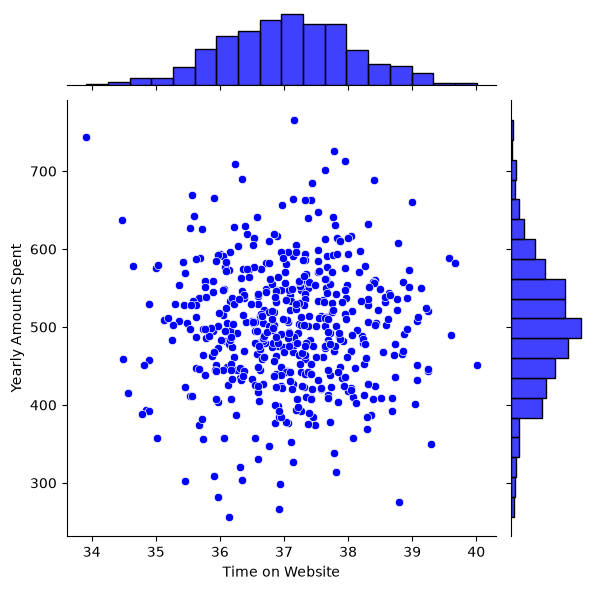

In [42]:
sns.jointplot(data=df, x="Time on Website", y="Yearly Amount Spent", kind="scatter", color="blue")

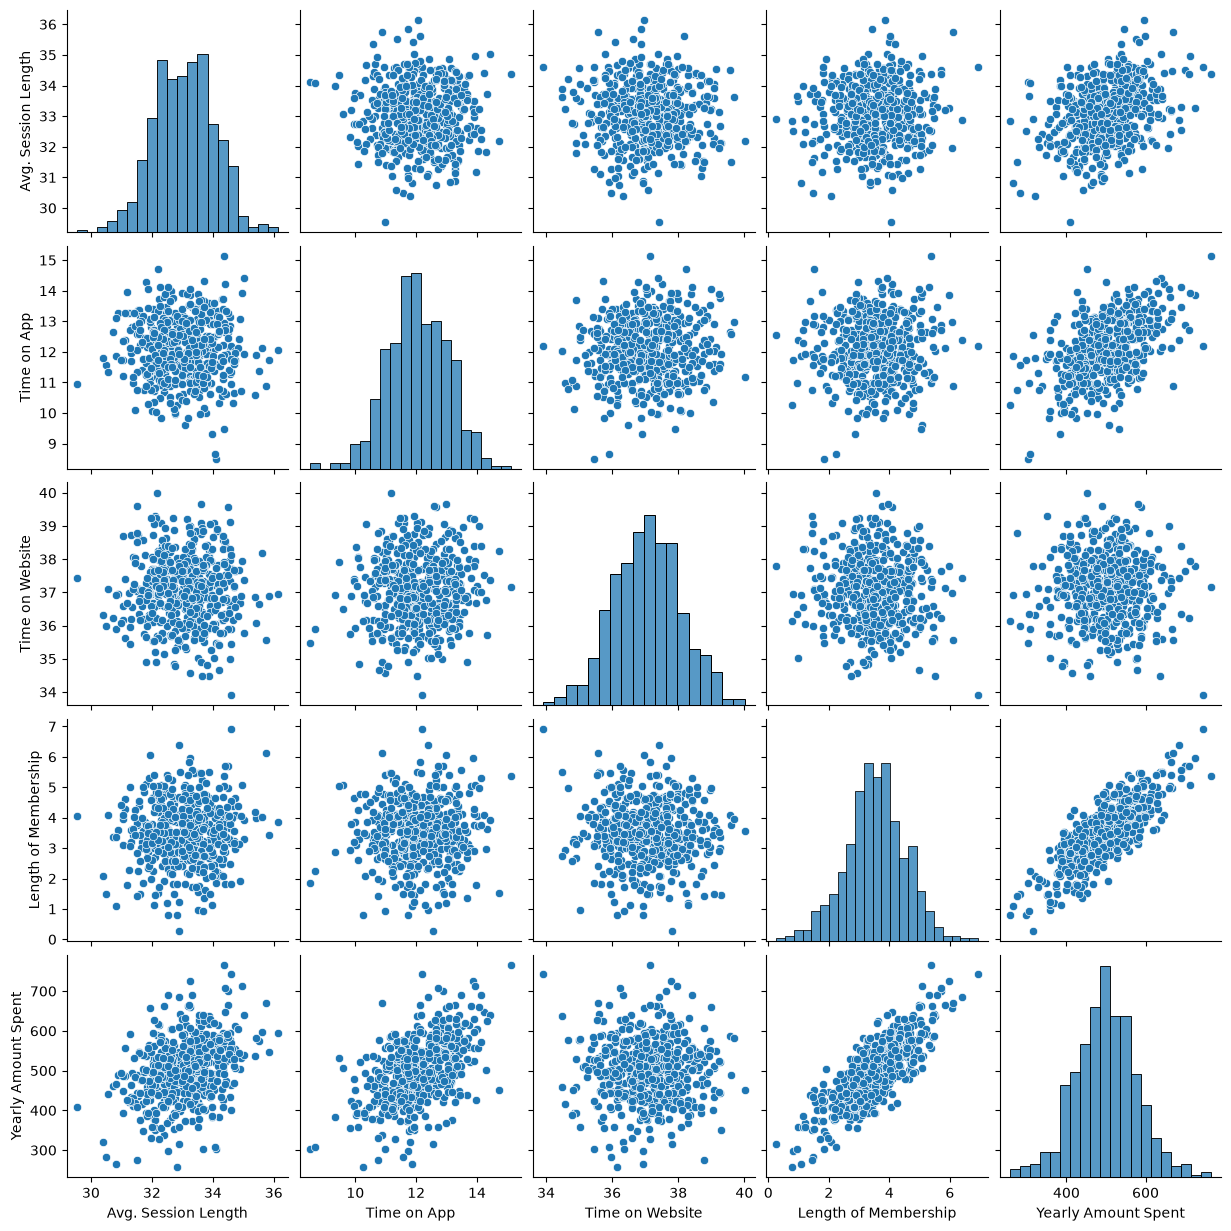

In [46]:
sns.pairplot(data=df, kind="scatter")

## Split the data using sikit learn

In [47]:
import sklearn
from sklearn.model_selection import train_test_split
X = df[["Avg. Session Length", "Time on App", "Time on Website", "Length of Membership"]]
y = df["Yearly Amount Spent"]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=505)

In [49]:
x_test

,Avg. Session Length,Time on App,Time on Website,Length of Membership
193,31.570201,13.378063,36.337800,4.369367
226,32.299647,12.168596,37.073616,4.403370
287,33.908565,12.914847,39.068864,1.482360
472,33.665990,12.263718,38.860234,3.139527
394,32.430839,13.887275,38.381956,3.772969
...,...,...,...,...
298,33.622592,11.167357,35.626587,5.462501
354,32.386969,12.717995,35.128822,3.481062
146,32.116400,12.380695,37.232003,3.089528
67,32.805220,11.835476,36.375066,3.439591


# Training the Model using scikit learn

In [50]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[25.61,38.95, 0.59,61.77]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Avg. Session Length','Time on App','Time on Website', 'Length of Membership']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1057
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [52]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coefficients)

                      Coefficient
Avg. Session Length     25.614805
Time on App             38.954886
Time on Website          0.593999
Length of Membership    61.768109


In [56]:
accuracy = model.score(x_test, y_test)
print(f"Model Accuracy (R^2 score): {accuracy}")

Model Accuracy (R^2 score): 0.9832908221520792


## Evaluating Scikit learn model

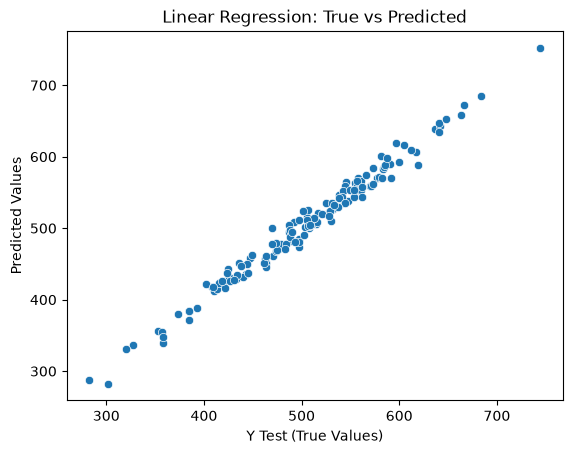

In [54]:
predictions = model.predict(x_test)
sns.scatterplot(x=y_test, y=predictions)
plt.xlabel("Y Test (True Values)")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: True vs Predicted")
plt.show()

In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

Mean Squared Error: 104.85789663659732
Mean Absolute Error: 8.1876858785743
R-squared: 0.9832908221520792


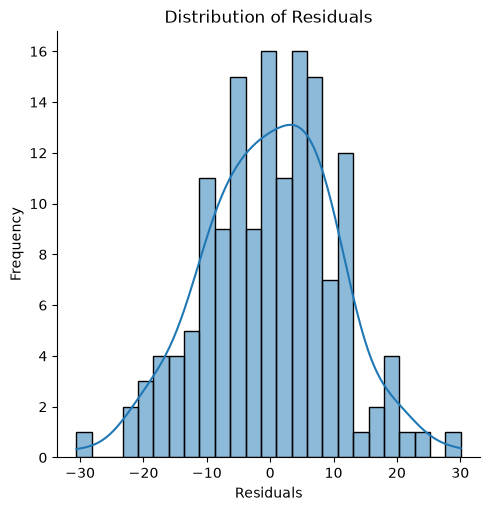

In [60]:
sns.displot(y_test - predictions, bins=25, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

# From scratch model

## Feature scaling


In [61]:
X_train_mean = x_train.mean()
X_train_std = x_train.std()

X_train_scaled = (x_train - X_train_mean) / X_train_std
X_test_scaled = (x_test - X_train_mean) / X_train_std

X_train_scaled.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership
480,1.231502,-0.519511,-1.306476,0.670811
220,1.107972,-0.476889,0.662484,0.165323
263,0.267973,0.445009,1.156468,-0.805531
29,0.071897,-0.094316,0.197934,1.231279
345,0.879771,-1.483011,0.895622,0.023596


## Implementing Linear Regression from scratch (Batch Gradient Descent)

In [62]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y

            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            cost = (1 / (2 * n_samples)) * np.sum(error ** 2)
            self.cost_history.append(cost)

    def predict(self, X):
        X = np.array(X)
        return np.dot(X, self.weights) + self.bias

## Training the from-scratch model

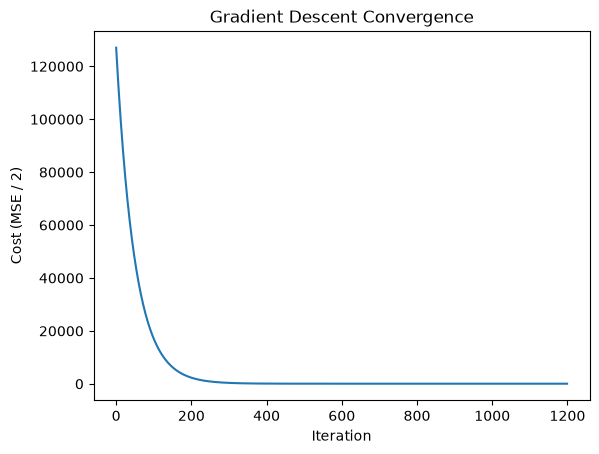

In [79]:
#learning rate = 0.01, n_iterations = 1200
scratch_model1 = LinearRegressionScratch(learning_rate=0.01, n_iterations=1200)
scratch_model1.fit(X_train_scaled, y_train)

plt.plot(range(scratch_model1.n_iterations), scratch_model1.cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE / 2)")
plt.title("Gradient Descent Convergence")
plt.show()

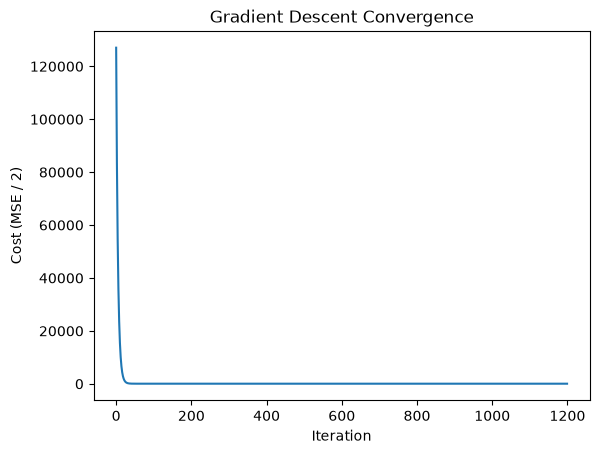

In [80]:
#learning rate = 0.1, n_iterations = 1200
scratch_model2 = LinearRegressionScratch(learning_rate=0.1, n_iterations=1200)
scratch_model2.fit(X_train_scaled, y_train)

plt.plot(range(scratch_model2.n_iterations), scratch_model2.cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE / 2)")
plt.title("Gradient Descent Convergence")
plt.show()

In [88]:
scratch_coefficients1 = pd.DataFrame(scratch_model1.weights, X.columns, columns=["Coefficient with learning rate 0.01"])
print(scratch_coefficients1)
print(f"Bias (intercept): {scratch_model1.bias}")
print("")
scratch_coefficients2 = pd.DataFrame(scratch_model2.weights, X.columns, columns=["Coefficient with learning rate 0.1"])
print(scratch_coefficients2)
print(f"Bias (intercept): {scratch_model2.bias}")

                      Coefficient with learning rate 0.01
Avg. Session Length                             25.022933
Time on App                                     37.994853
Time on Website                                  0.595985
Length of Membership                            61.653786
Bias (intercept): 497.8016346536438

                      Coefficient with learning rate 0.1
Avg. Session Length                            25.022802
Time on App                                    37.995208
Time on Website                                 0.595607
Length of Membership                           61.654096
Bias (intercept): 497.8045139896452


## Evaluating the from-scratch model

In [90]:
scratch_predictions1 = scratch_model1.predict(X_test_scaled)
scratch_predictions2 = scratch_model2.predict(X_test_scaled)

def r2_score_scratch(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def mse_scratch(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae_scratch(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

scratch_mse1 = mse_scratch(y_test, scratch_predictions1)
scratch_mae1 = mae_scratch(y_test, scratch_predictions1)
scratch_r21 = r2_score_scratch(y_test, scratch_predictions1)

scratch_mse2 = mse_scratch(y_test, scratch_predictions2)
scratch_mae2 = mae_scratch(y_test, scratch_predictions2)
scratch_r22 = r2_score_scratch(y_test, scratch_predictions2)

print(f"From-Scratch Model 1 — Mean Squared Error: {scratch_mse1}")
print(f"From-Scratch Model 1 — Mean Absolute Error: {scratch_mae1}")
print(f"From-Scratch Model 1 — R-squared: {scratch_r21}")

print("")

print(f"From-Scratch Model 2 — Mean Squared Error: {scratch_mse2}")
print(f"From-Scratch Model 2 — Mean Absolute Error: {scratch_mae2}")
print(f"From-Scratch Model 2 — R-squared: {scratch_r22}")

From-Scratch Model 1 — Mean Squared Error: 104.85736594949259
From-Scratch Model 1 — Mean Absolute Error: 8.187712988675171
From-Scratch Model 1 — R-squared: 0.9832909067174338

From-Scratch Model 2 — Mean Squared Error: 104.85789663659688
From-Scratch Model 2 — Mean Absolute Error: 8.187685878574287
From-Scratch Model 2 — R-squared: 0.9832908221520793


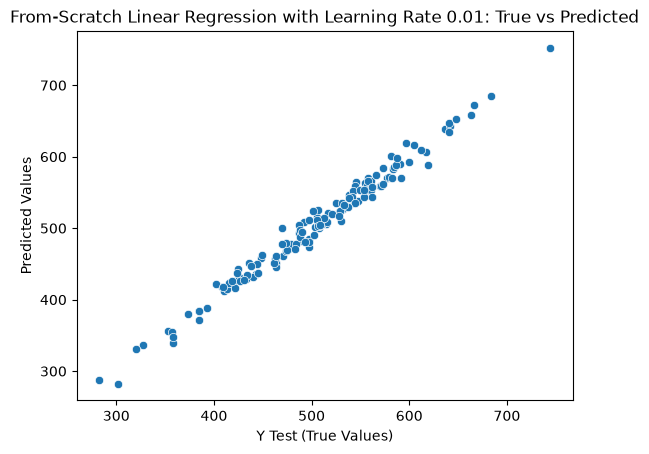

In [93]:
sns.scatterplot(x=y_test, y=scratch_predictions1)
plt.xlabel("Y Test (True Values)")
plt.ylabel("Predicted Values")
plt.title("From-Scratch Linear Regression with Learning Rate 0.01: True vs Predicted")
plt.show()

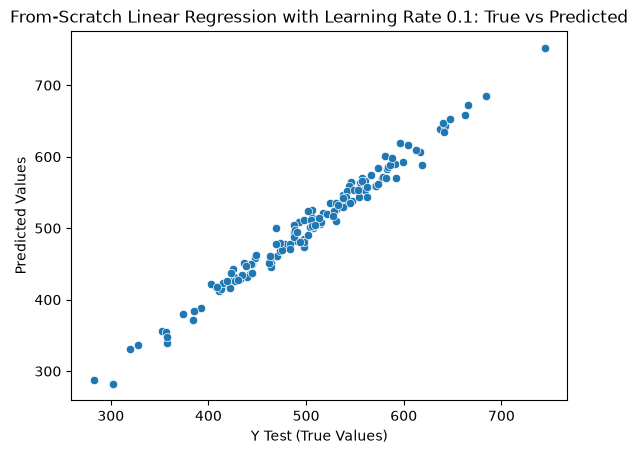

In [94]:
sns.scatterplot(x=y_test, y=scratch_predictions2)
plt.xlabel("Y Test (True Values)")
plt.ylabel("Predicted Values")
plt.title("From-Scratch Linear Regression with Learning Rate 0.1: True vs Predicted")
plt.show()

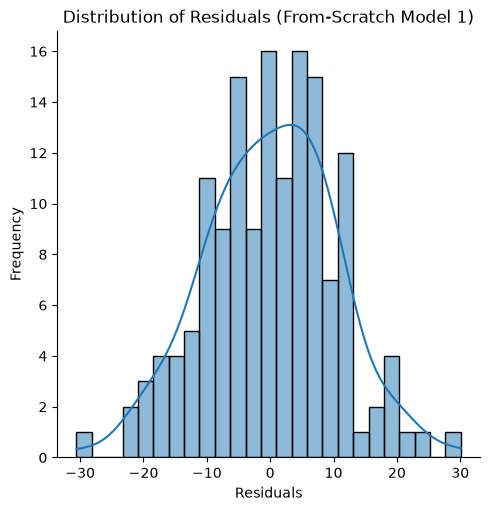

In [95]:
sns.displot(y_test - scratch_predictions1, bins=25, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals (From-Scratch Model 1)")
plt.show()

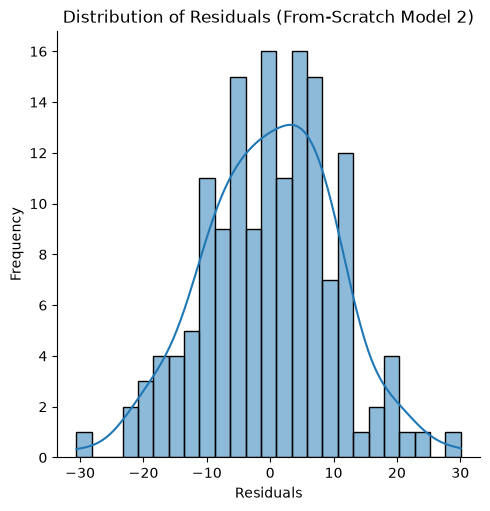

In [96]:
sns.displot(y_test - scratch_predictions2, bins=25, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals (From-Scratch Model 2)")
plt.show()

## Scikit-learn vs. From-scratch comparison

In [98]:
comparison_df = pd.DataFrame({
    "Metric": ["Mean Squared Error", "Mean Absolute Error", "R-squared"],
    "Scikit-learn Model": [mse, mae, r2],
    "From-Scratch Model 1": [scratch_mse1, scratch_mae1, scratch_r21],
    "From-Scratch Model 2": [scratch_mse2, scratch_mae2, scratch_r22]
})
comparison_df

,Metric,Scikit-learn Model,From-Scratch Model 1,From-Scratch Model 2
0,Mean Squared Error,104.857897,104.857366,104.857897
1,Mean Absolute Error,8.187686,8.187713,8.187686
2,R-squared,0.983291,0.983291,0.983291


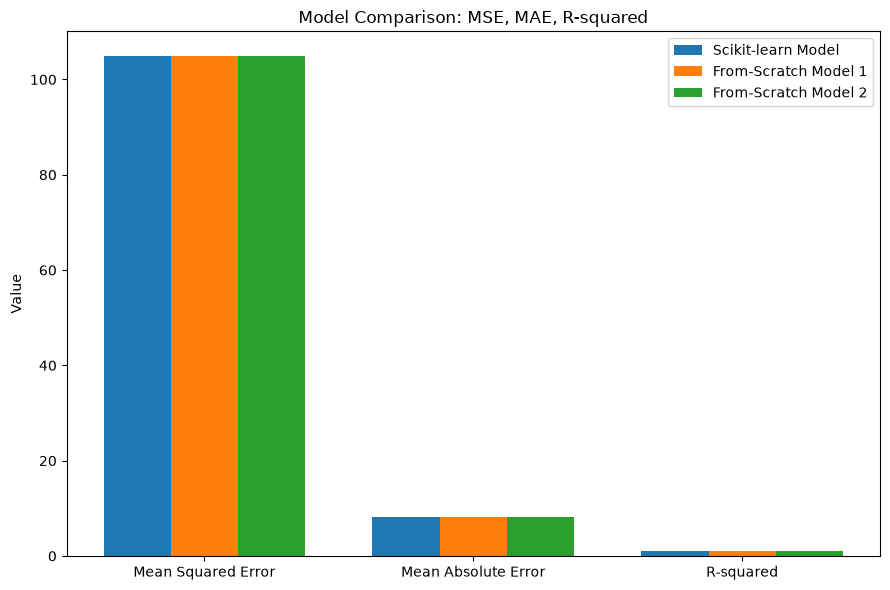

In [101]:
metrics = comparison_df["Metric"]
models = ["Scikit-learn Model", "From-Scratch Model 1", "From-Scratch Model 2"]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 6))
for i, model in enumerate(models):
    ax.bar(x + (i - 1) * width, comparison_df[model], width, label=model)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Value")
ax.set_title("Model Comparison: MSE, MAE, R-squared")
ax.legend()
plt.tight_layout()
plt.show()